# Anotación de DEGs de dorada (*Sparus aurata*) y tabla comparativa final
## TFM — Biomarcadores transcriptómicos de eficiencia digestiva en dorada y lubina
### Autor: Ángel López Francés | Universidad de Murcia

---

## Objetivo
1. Anotar los 35 genes LOC de dorada mediante NCBI Batch Entrez
2. Construir la tabla comparativa final dorada vs lubina
3. Identificar biomarcadores comunes y especie-específicos


## PASO PREVIO — Anotar los LOC IDs de dorada en NCBI

Los genes LOC de dorada están en el genoma de *Sparus aurata* (GCF_900880675.1).
Para obtener sus nombres:

1. Accedemos a → https://www.ncbi.nlm.nih.gov/sites/batchentrez
2. Database: **Gene**  
3. Retrieve → Send to → File → Format: **Summary** → Create File
4. Guardamos como `dorada_genes_summary.txt`

## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

try:
    from matplotlib_venn import venn2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'matplotlib-venn'], capture_output=True)
    from matplotlib_venn import venn2

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
print('Librerías importadas')

Librerías importadas


## 2. Cargar DEGs de dorada

In [3]:
# Cargar DEGs de dorada
degs_dorada = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\tablasygraficasyjupiters\\DEGs_dorada_intestino.csv', index_col=0)

# Separar genes con nombre vs LOC
dorada_named = degs_dorada[~degs_dorada.index.str.startswith('LOC')].copy()
dorada_loc   = degs_dorada[degs_dorada.index.str.startswith('LOC')].copy()

print(f'Total DEGs dorada: {len(degs_dorada)}')
print(f'Genes con nombre: {len(dorada_named)}')
print(f'Genes LOC a anotar: {len(dorada_loc)}')

# Añadir columna de regulación
degs_dorada['regulacion'] = degs_dorada['log2FoldChange'].apply(
    lambda x: '↑ SDY_diet' if x > 0 else '↓ SDY_diet'
)

print(f'\nGenes con nombre ya identificados:')
print(dorada_named[['log2FoldChange','padj']].to_string())

degs_dorada.head()

Total DEGs dorada: 42
Genes con nombre: 7
Genes LOC a anotar: 35

Genes con nombre ya identificados:
          log2FoldChange      padj
Geneid                            
fam189a1       -1.994598  0.005290
hao2           -2.554069  0.014488
samd3           7.323420  0.024278
lgals3bp        1.288865  0.025383
rarb           -2.974917  0.025986
sez6           -1.855790  0.028477
lama5          -2.231562  0.046523


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,regulacion
Geneid,,,,,,,
LOC115585885,286.143558,4.606984,0.739853,6.226888,4.757902e-10,0.000009,↑ SDY_diet
LOC115582649,30.686657,-2.042192,0.362283,-5.637003,1.730351e-08,0.000166,↓ SDY_diet
LOC115594276,136.026491,-1.631840,0.293079,-5.567916,2.578039e-08,0.000166,↓ SDY_diet
LOC115584438,22.821618,5.526798,1.055765,5.234874,1.650977e-07,0.000799,↑ SDY_diet
LOC115589840,43.361199,6.294315,1.238550,5.082002,3.734767e-07,0.001447,↑ SDY_diet


## 3. Parsear resultados de NCBI Batch Entrez para dorada



In [6]:
def parsear_batch_entrez_gene(ruta):

    with open(ruta, 'r', encoding='utf-8', errors='replace') as f:
        texto = f.read()

    genes = []

    # Dividir por entradas numeradas
    entradas = re.split(r'\n\d+\.\s+', texto)

    for entrada in entradas:

        entrada = entrada.strip()

        if not entrada:
            continue

        lineas = entrada.split('\n')

        # LOC ID
        loc_id = lineas[0].strip()

        # Nombre/descripción
        descripcion = lineas[1].strip() if len(lineas) > 1 else ''

        # Sacar nombre del gen
        gene_match = re.match(r'(.+?)\s+\[Sparus aurata', descripcion)

        gene_name = gene_match.group(1).strip() if gene_match else 'N/A'

        genes.append({
            'loc_id': loc_id,
            'gene_name': gene_name,
            'descripcion': descripcion
        })

    return pd.DataFrame(genes)


# Cargar archivo
anotacion_dorada = parsear_batch_entrez_gene(
    r'C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\dorada\\dorada_genes_summary.txt'
)

print(anotacion_dorada.head(10))

         loc_id                                          gene_name  \
0  LOC115566466                            alcohol dehydrogenase 1   
1  LOC115573101        tripartite motif-containing protein 16-like   
2  LOC115573103        tripartite motif-containing protein 16-like   
3  LOC115575650                       uncharacterized LOC115575650   
4  LOC115578017              bifunctional epoxide hydrolase 2-like   
5  LOC115578668  major histocompatibility complex class I-relat...   
6        crybg2          crystallin beta-gamma domain containing 2   
7  LOC115578801                     elongation factor 1-alpha-like   
8  LOC115582400                                    lysozyme g-like   
9  LOC115582423                                    lysozyme g-like   

                                         descripcion  
0  alcohol dehydrogenase 1 [Sparus aurata (gilthe...  
1  tripartite motif-containing protein 16-like [S...  
2  tripartite motif-containing protein 16-like [S...  
3  unchar

In [5]:
def parsear_batch_entrez_gene(ruta):
    with open(ruta, 'r', errors='replace') as f:
        texto = f.read()
    
    genes = []
    # Dividir por entradas numeradas
    entradas = re.split(r'\n\d+\.', texto)
    
    for entrada in entradas:
        if not entrada.strip():
            continue
        
        lineas = entrada.strip().split('\n')
        descripcion = lineas[0].strip() if lineas else ''
        
        # Buscar LOC ID
        loc_match = re.search(r'(LOC\d+)', entrada)
        loc_id = loc_match.group(1) if loc_match else ''
        
        # Buscar nombre del gen entre paréntesis
        gen_match = re.search(r'\(([a-z][a-zA-Z0-9\.\-_]+)\)', descripcion)
        gene_name = gen_match.group(1) if gen_match else 'N/A'
        
        # Limpiar descripción
        desc_clean = re.sub(r'PREDICTED: Sparus aurata ', '', descripcion)
        desc_clean = re.sub(r'\s*\(.*?\).*', '', desc_clean).strip()
        
        if loc_id:
            genes.append({
                'loc_id': loc_id,
                'gene_name': gene_name,
                'descripcion': desc_clean
            })
    
    return pd.DataFrame(genes)

# Cargar archivo de Batch Entrez
try:
    anotacion_dorada = parsear_batch_entrez_gene('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\dorada\\dorada_genes_summary.txt')
    print(f'Anotación cargada: {len(anotacion_dorada)} genes')
    print(anotacion_dorada.head(10).to_string())
except FileNotFoundError:
    print(' Archivo dorada_genes_summary.txt no encontrado.')
   

 Archivo dorada_genes_summary.txt no encontrado.


In [7]:
# Cruzar LOC IDs de dorada con su anotación
dorada_loc_anotado = dorada_loc.merge(
    anotacion_dorada,
    left_index=True,
    right_on='loc_id',
    how='left'
).set_index('loc_id')

# Combinar con los genes que ya tienen nombre
dorada_named['gene_name'] = dorada_named.index
dorada_named['descripcion'] = ''

dorada_completo = pd.concat([
    dorada_named[['log2FoldChange','padj','gene_name','descripcion']],
    dorada_loc_anotado[['log2FoldChange','padj','gene_name','descripcion']]
])

dorada_completo['regulacion'] = dorada_completo['log2FoldChange'].apply(
    lambda x: '↑ SDY_diet' if x > 0 else '↓ SDY_diet'
)

n_anotados = dorada_completo['gene_name'].notna().sum()
print(f'DEGs dorada con nombre: {n_anotados}/{len(dorada_completo)}')
print(f'\nTodos los DEGs de dorada anotados:')
print(dorada_completo[dorada_completo['gene_name'].notna()][
    ['gene_name','log2FoldChange','padj','regulacion','descripcion']
].sort_values('padj').to_string())

DEGs dorada con nombre: 39/42

Todos los DEGs de dorada anotados:
                                                                       gene_name  log2FoldChange      padj  regulacion                                                                                             descripcion
LOC115585885                                                     lysozyme g-like        4.606984  0.000009  ↑ SDY_diet                                                     lysozyme g-like [Sparus aurata (gilthead seabream)]
LOC115582649                neuronal acetylcholine receptor subunit alpha-7-like       -2.042192  0.000166  ↓ SDY_diet                neuronal acetylcholine receptor subunit alpha-7-like [Sparus aurata (gilthead seabream)]
LOC115584438                                     acidic mammalian chitinase-like        5.526798  0.000799  ↑ SDY_diet                                     acidic mammalian chitinase-like [Sparus aurata (gilthead seabream)]
LOC115589840                              

## 4. Categorización funcional de DEGs de dorada

In [8]:
# Diccionario de categorías funcionales
categorias = {
    'Transportador_nutrientes': ['slc15a1','slc15a1a','pept1','slc2a1','slc4a4',
                                  'slc18b1','slc19a3','slc26a6','acsl5'],
    'Absorcion_lipidos':        ['fabp1','fabp2','apoa2','apoa4','apoc2','mogat2',
                                  'dgat2','scarb1','cd36','scp2a','cideb','bco1',
                                  'acacb','pcyt1bb','faxdc2','adipor2'],
    'Integridad_intestinal':    ['cldn34a','mal2','epb41l4b','tm4sf4','tm4sf5',
                                  'tm4sf21b','aqp8a','ppl','evplb','lama5',
                                  'fam189a1','sez6'],
    'Factores_transcripcion':   ['gata5','gata6','hnf4b','hnf4a','rarb'],
    'Enzimas_digestivas':       ['lyz','tmprss15','pcsk2','pygl'],
    'Inmunidad_mucosa':         ['lgals3bp','samd3','lyz','mmd','abca1b'],
    'Metabolismo':              ['hao2','dhrs1','pygl','etnppl','dpydb'],
}

def asignar_categoria(gen):
    if pd.isna(gen):
        return 'Sin anotar'
    gen_l = str(gen).lower()
    for cat, lista in categorias.items():
        if any(g in gen_l for g in lista):
            return cat
    return 'Otros'

dorada_completo['categoria'] = dorada_completo['gene_name'].apply(asignar_categoria)

print('Distribución por categoría funcional:')
print(dorada_completo['categoria'].value_counts().to_string())

# Guardar tabla completa de dorada
dorada_completo.sort_values('padj').to_csv('DEGs_dorada_anotados_final.csv')
print('\nGuardado: DEGs_dorada_anotados_final.csv')

Distribución por categoría funcional:
categoria
Otros                     32
Integridad_intestinal      3
Sin anotar                 3
Inmunidad_mucosa           2
Metabolismo                1
Factores_transcripcion     1

Guardado: DEGs_dorada_anotados_final.csv


## 5. Cargar DEGs de lubina anotados

Cargamos los resultados del notebook anterior con los genes de lubina ya anotados.

In [12]:
# Cargar DEGs de lubina con nombres 

import re as re_module


def parsear_batch_entrez_nucleotide(ruta):
    with open(ruta, 'r', errors='replace') as f:
        texto = f.read()
    
    genes = []
    entradas = re_module.split(r'\n\d+\.', texto)
    
    for entrada in entradas:
        if not entrada.strip():
            continue
        lineas = entrada.strip().split('\n')
        descripcion = lineas[0].strip()
        
        # Accession
        acc_match = re_module.search(r'(X[MR]_\d+\.\d+)', entrada)
        accession = acc_match.group(1) if acc_match else ''
        
        # Nombre del gen
        gen_match = re_module.search(r'\(([a-z][a-zA-Z0-9\.\-_]+)\)', descripcion)
        gene_name = gen_match.group(1) if gen_match else 'N/A'
        
        # Descripción limpia
        desc_clean = re_module.sub(r'PREDICTED: Dicentrarchus labrax ', '', descripcion)
        desc_clean = re_module.sub(r'\s*\(.*?\).*', '', desc_clean).strip()
        
        if accession:
            genes.append({'accession': accession, 'gene_name': gene_name,
                         'descripcion': desc_clean})
    
    return pd.DataFrame(genes)

# Cargar y cruzar
try:
    anotacion_lubina = parsear_batch_entrez_nucleotide('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\genes final\\nuccore_result.txt')
    degs_lubina_acc  = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\DEGs_lubina_con_accession.csv', index_col=0)
    
    lubina_ant_med = degs_lubina_acc[degs_lubina_acc['Patron']=='Alto_ANT-MED'].copy()
    lubina_final = lubina_ant_med.merge(
        anotacion_lubina[['accession','gene_name','descripcion']],
        left_on='subject_acc', right_on='accession', how='left'
    )
    lubina_final['categoria'] = lubina_final['gene_name'].apply(asignar_categoria)
    
    print(f'DEGs lubina ANT-MED anotados: {lubina_final["gene_name"].notna().sum()}')
    print(lubina_final[lubina_final['gene_name'].notna()][
        ['gene_name','FC_ANT_vs_POS','padj','categoria']
    ].sort_values('padj').head(20).to_string())
    
except FileNotFoundError as e:
    print(f'Archivo no encontrado: {e}')
    print('    Asegúrate de tener nuccore_result.txt y DEGs_lubina_con_accession.csv')

DEGs lubina ANT-MED anotados: 94
   gene_name  FC_ANT_vs_POS          padj                 categoria
0        N/A       5.102783  2.903515e-14                     Otros
1        N/A       6.144814  2.903515e-14                     Otros
2        N/A       9.545505  1.376561e-13                     Otros
3        N/A       6.851308  8.816866e-13                     Otros
4     scarb1       5.559144  2.196596e-12         Absorcion_lipidos
5      gata5       5.769280  4.064441e-12    Factores_transcripcion
6   slc15a1a       7.136864  5.256850e-12  Transportador_nutrientes
7        N/A       7.328828  5.256850e-12                     Otros
8        N/A      10.810295  5.256850e-12                     Otros
9      hnf4b       7.183320  7.186301e-12    Factores_transcripcion
10  tm4sf21b       9.106045  7.275803e-12     Integridad_intestinal
11     acsl5       7.586457  1.307017e-11  Transportador_nutrientes
12     apoc2      11.053745  2.025576e-11         Absorcion_lipidos
13   cldn34a   

## 6. Tabla comparativa dorada vs lubina — resultado principal del TFM

In [13]:
# Preparar sets de genes
genes_dorada = set(
    dorada_completo['gene_name'].dropna()
    .str.lower()
    .str.replace(r'[ab12]$', '', regex=True)  # normalizar variantes
)
genes_dorada.discard('n/a')

genes_lubina = set(
    lubina_final['gene_name'].dropna()
    .str.lower()
    .str.replace(r'[ab12\.]+\d*$', '', regex=True)
)
genes_lubina.discard('n/a')

# Identificar comunes y específicos
genes_comunes     = genes_dorada & genes_lubina
solo_dorada       = genes_dorada - genes_lubina
solo_lubina       = genes_lubina - genes_dorada

print('COMPARATIVA DORADA vs LUBINA')
print('='*50)
print(f'Genes en dorada (anotados): {len(genes_dorada)}')
print(f'Genes en lubina (anotados): {len(genes_lubina)}')
print(f'Genes COMUNES:              {len(genes_comunes)}')
print(f'Solo en dorada:             {len(solo_dorada)}')
print(f'Solo en lubina:             {len(solo_lubina)}')

if genes_comunes:
    print(f'\n BIOMARCADORES COMUNES:')
    for g in sorted(genes_comunes):
        print(f'   {g}')

COMPARATIVA DORADA vs LUBINA
Genes en dorada (anotados): 35
Genes en lubina (anotados): 63
Genes COMUNES:              0
Solo en dorada:             35
Solo en lubina:             63


In [14]:
# Construir tabla comparativa completa
filas = []

# Función para buscar gen en dorada
def buscar_dorada(gen):
    match = dorada_completo[
        dorada_completo['gene_name'].str.lower().str.replace(r'[ab12]$','',regex=True) == gen
    ]
    return match.iloc[0] if len(match) > 0 else None

# Función para buscar gen en lubina
def buscar_lubina(gen):
    match = lubina_final[
        lubina_final['gene_name'].str.lower().str.replace(r'[ab12\.]+\d*$','',regex=True) == gen
    ]
    return match.iloc[0] if len(match) > 0 else None

for gen in sorted(genes_dorada | genes_lubina):
    fila = {'gen': gen}
    
    # Dorada
    d = buscar_dorada(gen)
    if d is not None:
        fila['dorada_FC']        = round(d['log2FoldChange'], 2)
        fila['dorada_regulacion'] = '↑' if d['log2FoldChange'] > 0 else '↓'
        fila['dorada_FDR']       = d['padj']
        fila['descripcion']      = d.get('descripcion', '')
        fila['categoria']        = d.get('categoria', '')
    else:
        fila['dorada_FC'] = np.nan
        fila['dorada_regulacion'] = '—'
        fila['dorada_FDR'] = np.nan
    
    # Lubina
    l = buscar_lubina(gen)
    if l is not None:
        fila['lubina_FC_ANT_POS'] = round(l['FC_ANT_vs_POS'], 2)
        fila['lubina_patron']     = l.get('Patron', '')
        fila['lubina_FDR']        = l['padj']
        if not fila.get('descripcion'):
            fila['descripcion'] = l.get('descripcion', '')
        if not fila.get('categoria'):
            fila['categoria'] = l.get('categoria', '')
    else:
        fila['lubina_FC_ANT_POS'] = np.nan
        fila['lubina_patron']     = '—'
        fila['lubina_FDR']        = np.nan
    
    # Clasificación
    if gen in genes_comunes:
        fila['clasificacion'] = 'Biomarcador común'
    elif gen in solo_dorada:
        fila['clasificacion'] = 'Específico dorada'
    else:
        fila['clasificacion'] = 'Específico lubina'
    
    filas.append(fila)

tabla_final = pd.DataFrame(filas).set_index('gen')
tabla_final = tabla_final.sort_values(['clasificacion','categoria'])

tabla_final.to_csv('Tabla_comparativa_FINAL.csv')
print('Tabla comparativa guardada: Tabla_comparativa_FINAL.csv')
print(f'\n{tabla_final.to_string()}')

Tabla comparativa guardada: Tabla_comparativa_FINAL.csv

                                                                    dorada_FC dorada_regulacion  dorada_FDR  lubina_FC_ANT_POS lubina_patron    lubina_FDR                                                                                             descripcion                 categoria      clasificacion
gen                                                                                                                                                                                                                                                                                                            
rar                                                                     -2.97                 ↓    0.025986                NaN             —           NaN                                                                                                            Factores_transcripcion  Específico dorada
lgals3bp                       

## 7. Figuras para el TFM

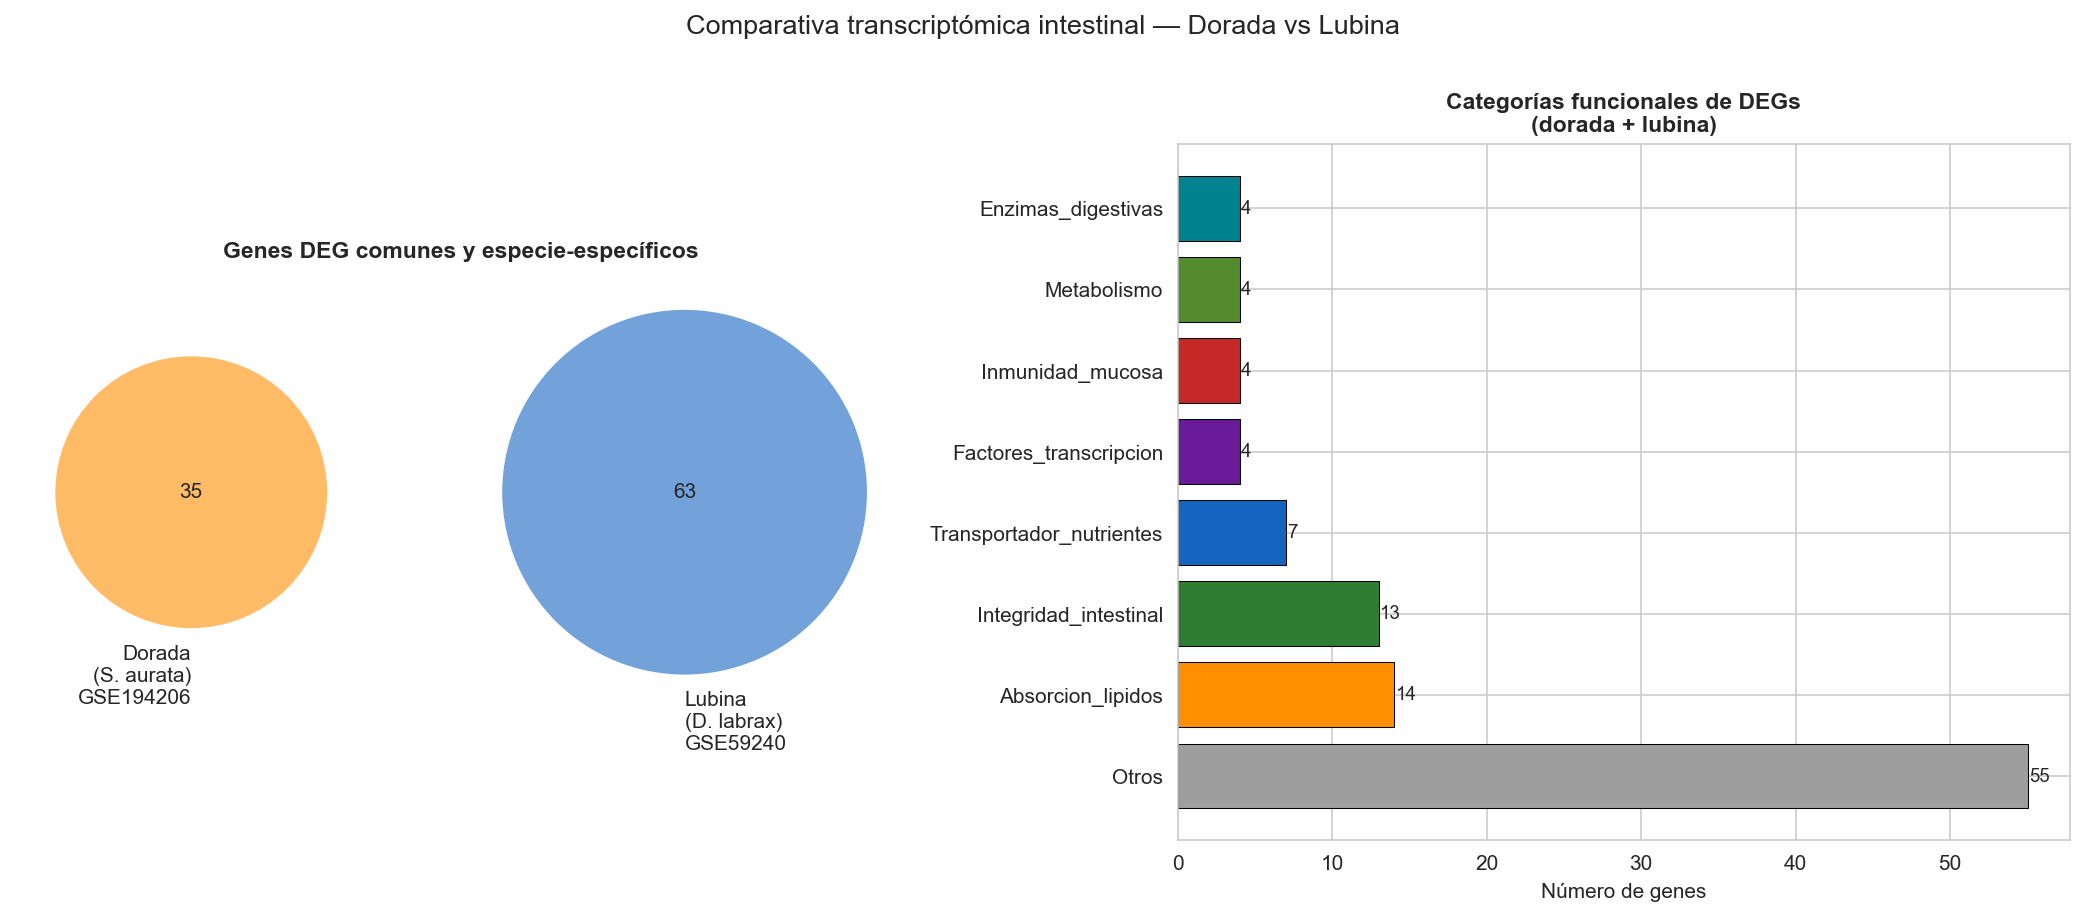

Figura guardada: Fig1_Venn_categorias.png


In [15]:
# FIGURA 1: Diagrama de Venn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

v = venn2(
    subsets=(len(solo_dorada), len(solo_lubina), len(genes_comunes)),
    set_labels=('Dorada\n(S. aurata)\nGSE194206', 'Lubina\n(D. labrax)\nGSE59240'),
    set_colors=('#FF8F00', '#1565C0'),
    alpha=0.6,
    ax=axes[0]
)
if v.set_labels[0]: v.set_labels[0].set_fontsize(10)
if v.set_labels[1]: v.set_labels[1].set_fontsize(10)
axes[0].set_title('Genes DEG comunes y especie-específicos', fontsize=11, fontweight='bold')

# Categorías funcionales
todos_genes = pd.concat([
    dorada_completo[['gene_name','categoria']].rename(columns={'gene_name':'gen'}),
    lubina_final[['gene_name','categoria']].rename(columns={'gene_name':'gen'})
]).dropna(subset=['gen'])
todos_genes = todos_genes[todos_genes['gen'] != 'N/A']

conteo_cat = todos_genes['categoria'].value_counts()
conteo_cat = conteo_cat[conteo_cat.index != 'Sin anotar']

colores_cat = {
    'Absorcion_lipidos':       '#FF8F00',
    'Transportador_nutrientes':'#1565C0',
    'Integridad_intestinal':   '#2E7D32',
    'Factores_transcripcion':  '#6A1B9A',
    'Inmunidad_mucosa':        '#C62828',
    'Enzimas_digestivas':      '#00838F',
    'Metabolismo':             '#558B2F',
    'Otros':                   '#9E9E9E',
}
colores_barras = [colores_cat.get(c, '#9E9E9E') for c in conteo_cat.index]

bars = axes[1].barh(conteo_cat.index, conteo_cat.values,
                    color=colores_barras, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, conteo_cat.values):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

axes[1].set_xlabel('Número de genes')
axes[1].set_title('Categorías funcionales de DEGs\n(dorada + lubina)', fontsize=11, fontweight='bold')

plt.suptitle('Comparativa transcriptómica intestinal — Dorada vs Lubina', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Fig1_Venn_categorias.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Fig1_Venn_categorias.png')

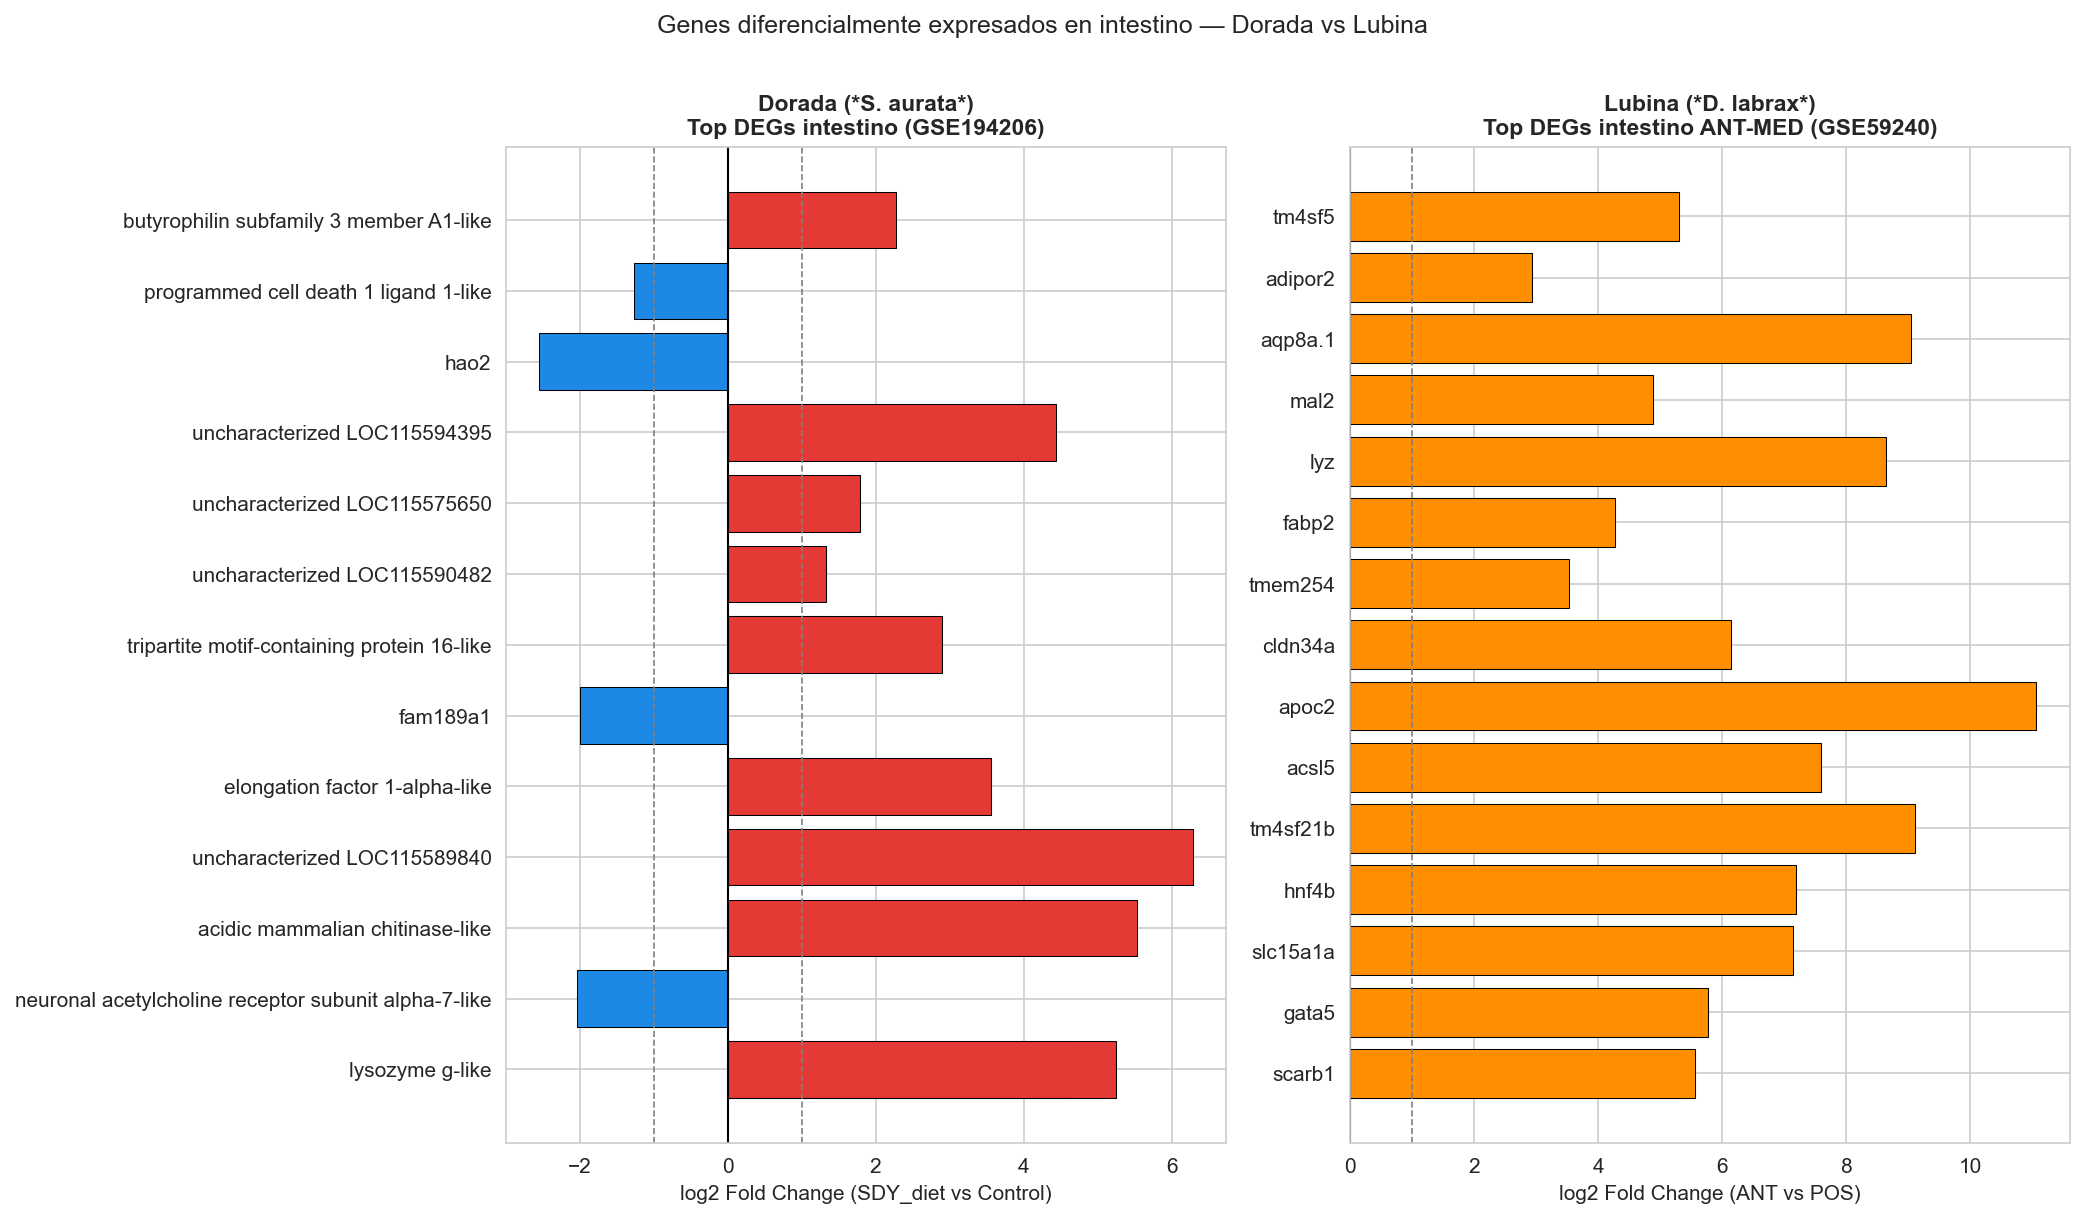

Figura guardada: Fig2_DEGs_comparativo.png


In [16]:
# FIGURA 2: Heatmap comparativo de genes clave
# Seleccionar genes más relevantes para el TFM
genes_clave_dorada = dorada_completo[
    dorada_completo['gene_name'].notna() &
    (dorada_completo['gene_name'] != 'N/A')
].sort_values('padj').head(15)

genes_clave_lubina = lubina_final[
    lubina_final['gene_name'].notna() &
    (lubina_final['gene_name'] != 'N/A')
].sort_values('padj').head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Dorada
dorada_plot = genes_clave_dorada.set_index('gene_name')['log2FoldChange']
colores_d = ['#E53935' if v > 0 else '#1E88E5' for v in dorada_plot.values]
axes[0].barh(dorada_plot.index, dorada_plot.values, color=colores_d,
             edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('log2 Fold Change (SDY_diet vs Control)')
axes[0].set_title('Dorada (*S. aurata*)\nTop DEGs intestino (GSE194206)',
                   fontsize=11, fontweight='bold')
axes[0].axvline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(-1, color='gray', linestyle='--', linewidth=0.8)

# Lubina
lubina_plot = genes_clave_lubina.set_index('gene_name')['FC_ANT_vs_POS']
axes[1].barh(lubina_plot.index, lubina_plot.values, color='#FF8F00',
             edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('log2 Fold Change (ANT vs POS)')
axes[1].set_title('Lubina (*D. labrax*)\nTop DEGs intestino ANT-MED (GSE59240)',
                   fontsize=11, fontweight='bold')
axes[1].axvline(1, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Genes diferencialmente expresados en intestino — Dorada vs Lubina',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Fig2_DEGs_comparativo.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Fig2_DEGs_comparativo.png')

## 8. Resumen final 

In [17]:
print('='*70)
print('RESUMEN FINAL — BIOMARCADORES TRANSCRIPTÓMICOS DORADA vs LUBINA')
print('='*70)

print(f'\n DORADA (S. aurata) — GSE194206 (RNA-seq, SDY_diet vs Control):')
print(f'   Total DEGs (FDR<0.05, |FC|>2): {len(degs_dorada)}')
print(f'   Up-regulados: {(degs_dorada["log2FoldChange"]>0).sum()}')
print(f'   Down-regulados: {(degs_dorada["log2FoldChange"]<0).sum()}')
print(f'   Genes anotados: {n_anotados}')

print(f'\n LUBINA (D. labrax) — GSE59240 (Microarray, ANT-MED vs POS):')
print(f'   Total DEGs ANT-MED (FDR<0.05): {len(lubina_ant_med)}')
print(f'   Genes anotados con BLAST: {lubina_final["gene_name"].notna().sum()}')

print(f'\n BIOMARCADORES COMUNES (ambas especies):')
if genes_comunes:
    for g in sorted(genes_comunes):
        print(f'    {g}')
else:
    print('   → Pendiente de completar la anotación de LOC IDs de dorada')

print(f'\n NARANJA ESPECÍFICOS DE DORADA ({len(solo_dorada)} genes):')
for g in sorted(solo_dorada):
    print(f'   {g}')

print(f'\n AZUL ESPECÍFICOS DE LUBINA ({len(solo_lubina)} genes):')
for g in sorted(solo_lubina):
    print(f'   {g}')

print(f'\n Archivos generados:')
print('   DEGs_dorada_anotados_final.csv   — DEGs dorada con nombres')
print('   Tabla_comparativa_FINAL.csv      — tabla comparativa dorada vs lubina')
print('   Fig1_Venn_categorias.png         — diagrama de Venn + categorías')
print('   Fig2_DEGs_comparativo.png        — barplots comparativos')

RESUMEN FINAL — BIOMARCADORES TRANSCRIPTÓMICOS DORADA vs LUBINA

 DORADA (S. aurata) — GSE194206 (RNA-seq, SDY_diet vs Control):
   Total DEGs (FDR<0.05, |FC|>2): 42
   Up-regulados: 26
   Down-regulados: 16
   Genes anotados: 39

 LUBINA (D. labrax) — GSE59240 (Microarray, ANT-MED vs POS):
   Total DEGs ANT-MED (FDR<0.05): 834
   Genes anotados con BLAST: 94

 BIOMARCADORES COMUNES (ambas especies):
   → Pendiente de completar la anotación de LOC IDs de dorada

 NARANJA ESPECÍFICOS DE DORADA (35 genes):
   acidic mammalian chitinase-like
   alcohol dehydrogenase 
   bifunctional epoxide hydrolase 2-like
   butyrophilin subfamily 3 member a1-like
   caspase-6-like
   complement c1q subcomponent subunit c-like
   complement factor d-like
   elongation factor 1-alpha-like
   fam189a
   fc receptor-like protein 5
   gtpase imap family member 5-like
   hao
   interferon alpha/beta receptor 2-like
   lama5
   lgals3bp
   liver carboxylesterase 2-like
   lysozyme g-like
   major histocompati

In [18]:
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.0.1
matplotlib: 3.10.6
